In [31]:
from PIL import Image
import numpy as np
ori_img = Image.open("data/original_image.png")
img = Image.open("StegaStamp-pytorch/outputs/demo/watermarked_output_hidden.png").convert("RGB")
wm = Image.open("data/raw_watermark.png").convert("L")

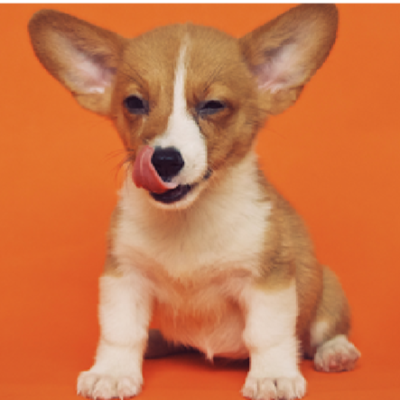

In [36]:
ori_img

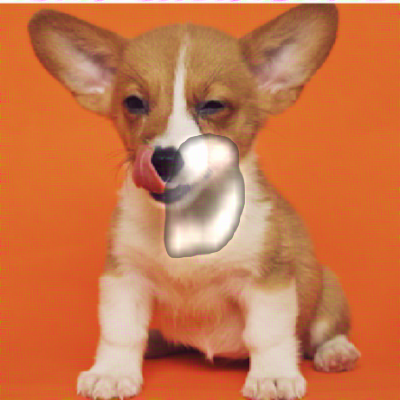

In [37]:
img

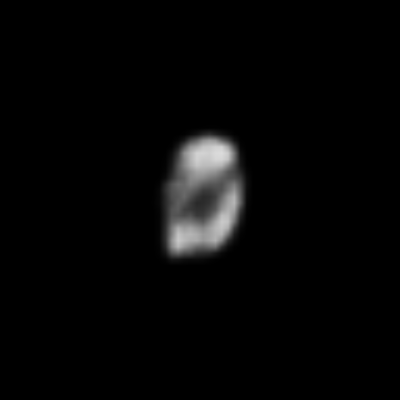

In [38]:
wm

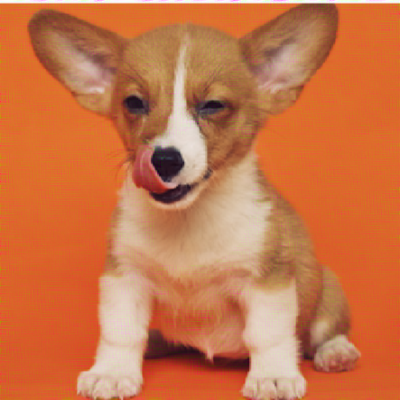

In [33]:
# Convert to arrays
img_arr = np.array(img)
mask_arr = 1-np.array(wm)
ori_arr = np.array(ori_img)
# Normalize mask to 0 and 1, then expand dimensions to match (H, W, 3)
mask_normalized = (mask_arr <= 1).astype(np.uint8)[:, :, np.newaxis]

# Multiply image by mask
masked_arr = img_arr * mask_normalized + ori_arr * (1 - mask_normalized)

# Display
imgf = Image.fromarray(masked_arr)
imgf


In [ ]:
imgf.save("pseudoRecreated.png")

In [39]:
!python -m StegaStamp-pytorch.stegastamp.decode_image --model ./StegaStamp-pytorch/asset/best.pth  --image ./pseudoRecreated.png --height 400 --width 400 --secret_size 100

sheru


### Lets check jpg compression performance on watermarked image

In [64]:
import os
import subprocess

# 1. Setup parameters
qualities = np.linspace(95, 15, 5)
results = [] # To store 1 for success, 0 for failure

for q in qualities:
    output_path = f"watermark_comp_{q}.jpg"

    img.convert("RGB").save(output_path, "JPEG", quality=int(q))
    
    # 2. Run command and capture output
    cmd = [
        "python", "-m", "StegaStamp-pytorch.stegastamp.decode_image",
        "--model", "./StegaStamp-pytorch/asset/best.pth",
        "--image", output_path,
        "--height", "400", "--width", "400",
        "--secret_size", "100"
    ]
    
    process = subprocess.run(cmd, capture_output=True, text=True)
    output = process.stdout + process.stderr
    
    # 3. Check for failure string
    if "decode failed" in output.lower():
        print(f"Quality {q}: Decode Failed")
        results.append(0)
    else:
        print(f"Quality {q}: Secret is {output}")
        results.append(1)



Quality 95.0: Secret is sheru

Quality 75.0: Secret is sheru

Quality 55.0: Secret is sheru

Quality 35.0: Decode Failed
Quality 15.0: Decode Failed


In [63]:
import os
import subprocess

# 1. Setup parameters
qualities = np.linspace(95, 15, 5)
results = [] # To store 1 for success, 0 for failure

for q in qualities:
    output_path = f"perfect_recreated_{q}.jpg"
    imgf.convert("RGB").save(output_path, "JPEG", quality=int(q))
    
    # 2. Run command and capture output
    cmd = [
        "python", "-m", "StegaStamp-pytorch.stegastamp.decode_image",
        "--model", "./StegaStamp-pytorch/asset/best.pth",
        "--image", output_path,
        "--height", "400", "--width", "400",
        "--secret_size", "100"
    ]
    
    process = subprocess.run(cmd, capture_output=True, text=True)
    output = process.stdout + process.stderr
    
    # 3. Check for failure string
    if "decode failed" in output.lower():
        print(f"Quality {q}: Decode Failed")
        results.append(0)
    else:
        print(f"Quality {q}: Secret is {output}")
        results.append(1)



Quality 95.0: Secret is sheru

Quality 75.0: Secret is sheru

Quality 55.0: Secret is rhe2u `

Quality 35.0: Decode Failed
Quality 15.0: Decode Failed
